# 01 · Data pipeline — step by step

The five stages from the TCC slides, on the **real** data, with intermediate
outputs shown at every step:

1. **Load** — 14 of 100 columns, GPU nodes only, `CANCELLED` excluded
2. **Label** — `1` in the 2 h before a failure job's `end_date`
3. **Split** — temporal 80/20 by job `end_date`
4. **Window** — 40-snapshot sliding window → `min/max/mean/std` (32 features)
5. **Validate** — confirm the inline logic reproduces the saved `artifacts/`

In [1]:
# --- make the benchmark/ package importable from notebooks/ ---
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / 'benchmark').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print('project root:', ROOT)

project root: D:\_fcall\UNIFEI\tcc\hpc_workload


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.edgecolor': '#c3c2b7', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.labelcolor': '#52514e', 'text.color': '#0b0b0b', 'figure.facecolor': 'white',
})
BLUE, MUTED, BAD, LIGHTBLUE = '#2a78d6', '#898781', '#d03b3b', '#9ec5f4'

In [3]:
import benchmark.config as C
import numpy as np, pandas as pd
import pyarrow.parquet as pq

## 1 · Load — column projection + `gpu_node=1` predicate

In [4]:
cols = C.FEATURES + C.SCAFFOLD
ds = pq.ParquetDataset(str(C.DATASET_PATH), filters=[('gpu_node', '=', 1)])
df = ds.read(columns=cols).to_pandas()
df = df[df['state'] != 'CANCELLED'].reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['end_date']  = pd.to_datetime(df['end_date'])
print(f'{len(df):,} snapshots   {df["slurm_id"].nunique():,} jobs')
df['state'].value_counts()

11,144,842 snapshots   23,618 jobs


state
COMPLETED        6769458
TIMEOUT          3643280
FAILED            631137
OUT_OF_MEMORY      73016
NODE_FAIL          27951
Name: count, dtype: int64

## 2 · Label — `1` iff failure job **and** within 2 h of its `end_date`

The rule is two booleans AND-ed together, applied per snapshot.

In [5]:
is_failure   = df['state'].isin(C.FAILURE_STATES)
time_to_end  = df['end_date'] - df['timestamp']
in_prefail   = (time_to_end <= pd.Timedelta(hours=C.PRE_FAILURE_HOURS)) & (time_to_end >= pd.Timedelta(0))
df['label']  = (is_failure & in_prefail).astype(np.int8)
print('positive snapshots:', f"{int(df['label'].sum()):,}", f"({df['label'].mean():.4f})")
df['label'].value_counts()

positive snapshots: 425,974 (0.0382)


label
0    10718868
1      425974
Name: count, dtype: int64

### What the label looks like on one real job

A failure job's telemetry, with the **2 h pre-failure window shaded** (those snapshots
get `label = 1`). GPU temperature and memory are on separate axes because their scales
differ by ten orders of magnitude.

job 2082352  state=TIMEOUT  snapshots=5761


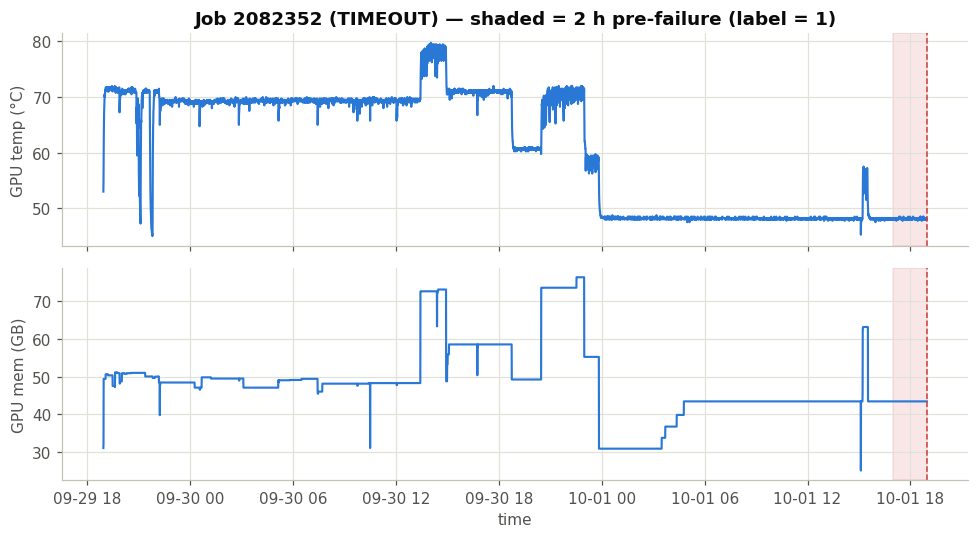

In [6]:
# pick a real failure job with a long-enough history (prefer the PDF's example id)
g = df[df['state'].isin(C.FAILURE_STATES)].groupby('slurm_id')
dur, cnt = g['end_date'].first() - g['timestamp'].min(), g.size()
cand = dur[(dur >= pd.Timedelta(hours=2.5)) & (cnt >= 400)].index
example_id = 1603441 if 1603441 in set(cand) else int(cand[len(cand)//2])

job = df[df['slurm_id'] == example_id].sort_values('timestamp')
end = job['end_date'].iloc[0]
print(f'job {example_id}  state={job["state"].iloc[0]}  snapshots={len(job)}')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
ax1.plot(job['timestamp'], job['nvidia_gpu_temperature_celsius_mean'], color=BLUE, lw=1.4)
ax1.set_ylabel('GPU temp (°C)')
ax2.plot(job['timestamp'], job['nvidia_gpu_memory_used_bytes_sum'] / 1e9, color=BLUE, lw=1.4)
ax2.set_ylabel('GPU mem (GB)')
for ax in (ax1, ax2):
    ax.axvspan(end - pd.Timedelta(hours=2), end, color=BAD, alpha=0.12)
    ax.axvline(end, color=BAD, lw=1, ls='--')
ax1.set_title(f'Job {example_id} ({job["state"].iloc[0]}) — shaded = 2 h pre-failure (label = 1)')
ax2.set_xlabel('time')
fig.tight_layout(); plt.show()

## 3 · Split — temporal, by job `end_date`

The first 80 % of jobs (ordered by when they *ended*) go to train. Splitting by whole
job keeps every snapshot of a job on one side of the cut — no leakage across the boundary.

In [7]:
job_end = df.groupby('slurm_id')['end_date'].first().sort_values()
n_train = int(len(job_end) * C.TRAIN_FRACTION)
train_set = set(job_end.iloc[:n_train].index)
print(f'train jobs: {n_train:,}   test jobs: {len(job_end) - n_train:,}')
print('split at end_date:', job_end.iloc[n_train])

train jobs: 18,894   test jobs: 4,724
split at end_date: 2022-10-19 11:50:16


## 4 · Sliding window — `min/max/mean/std` over 40 snapshots

Shown on one job: `sliding_window_view` turns `(n_snapshots, 8)` into
`(n_windows, 8, 40)`, then four reductions concatenate into a **32-feature** row per
window. Aggregations are done in `float64` (numerical safety on the ~1e10 byte metrics),
stored `float32`.

In [8]:
arr = job[C.FEATURES].to_numpy(np.float64)
win = np.lib.stride_tricks.sliding_window_view(arr, C.WINDOW_SIZE, axis=0)   # (n-39, 8, 40)
agg = np.concatenate([win.min(-1), win.max(-1), win.mean(-1), win.std(-1)], axis=1).astype(np.float32)
print(f'{len(job)} snapshots  ->  {agg.shape[0]} windows x {agg.shape[1]} features')
pd.DataFrame(agg[:3], columns=C.feature_names()).iloc[:, :8]   # first 3 windows, the 'min' block

5761 snapshots  ->  5722 windows x 32 features


,node_memory_Active_bytes_min,node_disk_written_bytes_total_sum_min,node_netstat_Tcp_InErrs_min,node_forks_total_min,nvidia_gpu_temperature_celsius_mean_min,nvidia_gpu_power_usage_milliwatts_mean_min,nvidia_gpu_memory_used_bytes_sum_min,nvidia_gpu_fanspeed_percent_mean_min
0,6.463750e+10,1.889904e+12,0.0,13573000.0,53.00,137867.00,3.106053e+10,44.25
1,6.874210e+10,1.890623e+12,0.0,13573400.0,54.75,154498.50,3.218447e+10,44.75
2,6.874210e+10,1.890624e+12,0.0,13573500.0,60.25,175122.75,4.939579e+10,45.50


## 5 · Validate — the inline logic reproduces the saved artifacts

Rebuild the windows for the **first training job** and check they equal the head of the
saved `X_train.npy`. If this passes, the notebook's transformation matches the package
that produced the artifacts.

In [9]:
sizes = df.groupby('slurm_id').size()
first_id = min(s for s in train_set if sizes[s] >= C.WINDOW_SIZE)   # first job in build order
j = df[df['slurm_id'] == first_id].sort_values('timestamp')
a = j[C.FEATURES].to_numpy(np.float64)
w = np.lib.stride_tricks.sliding_window_view(a, C.WINDOW_SIZE, axis=0)
mine = np.concatenate([w.min(-1), w.max(-1), w.mean(-1), w.std(-1)], axis=1).astype(np.float32)

X_train = np.load(C.artifact_path('X_train'), mmap_mode='r')
head = np.asarray(X_train[:len(mine)])
match = np.allclose(mine, head, rtol=1e-4, atol=1e-1)
print(f'first train job {first_id}: {mine.shape[0]} windows | matches saved X_train head: {match}')
print('max relative diff:', float(np.max(np.abs(mine - head) / (np.abs(head) + 1e-9))))

X_test = np.load(C.artifact_path('X_test'), mmap_mode='r')
y_train, y_test = np.load(C.artifact_path('y_train')), np.load(C.artifact_path('y_test'))
print(f'\nFinal artifacts:  X_train {X_train.shape} (pos {y_train.mean():.4f})   X_test {X_test.shape} (pos {y_test.mean():.4f})')

first train job 1907071: 9 windows | matches saved X_train head: True
max relative diff: 1.553608126414474e-05

Final artifacts:  X_train (9125945, 32) (pos 0.0320)   X_test (1411809, 32) (pos 0.0403)


> **Optional full rebuild.** Everything above traces the logic without recomputing all
> 10.5 M windows. To regenerate the artifacts from scratch (~2 min), flip the flag below.
> Off by default so this notebook stays fast and non-destructive.

In [10]:
REBUILD_FULL = False
if REBUILD_FULL:
    import benchmark.data_pipeline as DP
    DP.run(force=True)
else:
    print('Skipped full rebuild (REBUILD_FULL=False).')

Skipped full rebuild (REBUILD_FULL=False).
